In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO

In [3]:
#offcial Cariboo boundary that is going to give us the exact area to work with

In [4]:
WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"
}


# -----------------------------
response = requests.get(WFS_URL, params=params)
response.raise_for_status()


gdf = gpd.read_file(BytesIO(response.content))

print(f"Loaded {len(gdf)} fire zones")
print(gdf[["MOF_FIRE_CENTRE_NAME", "MOF_FIRE_ZONE_NAME"]])

Loaded 4 fire zones
  MOF_FIRE_CENTRE_NAME         MOF_FIRE_ZONE_NAME
0  Cariboo Fire Centre   100 Mile House Fire Zone
1  Cariboo Fire Centre        Chilcotin Fire Zone
2  Cariboo Fire Centre          Quesnel Fire Zone
3  Cariboo Fire Centre  Central Cariboo Fire Zone


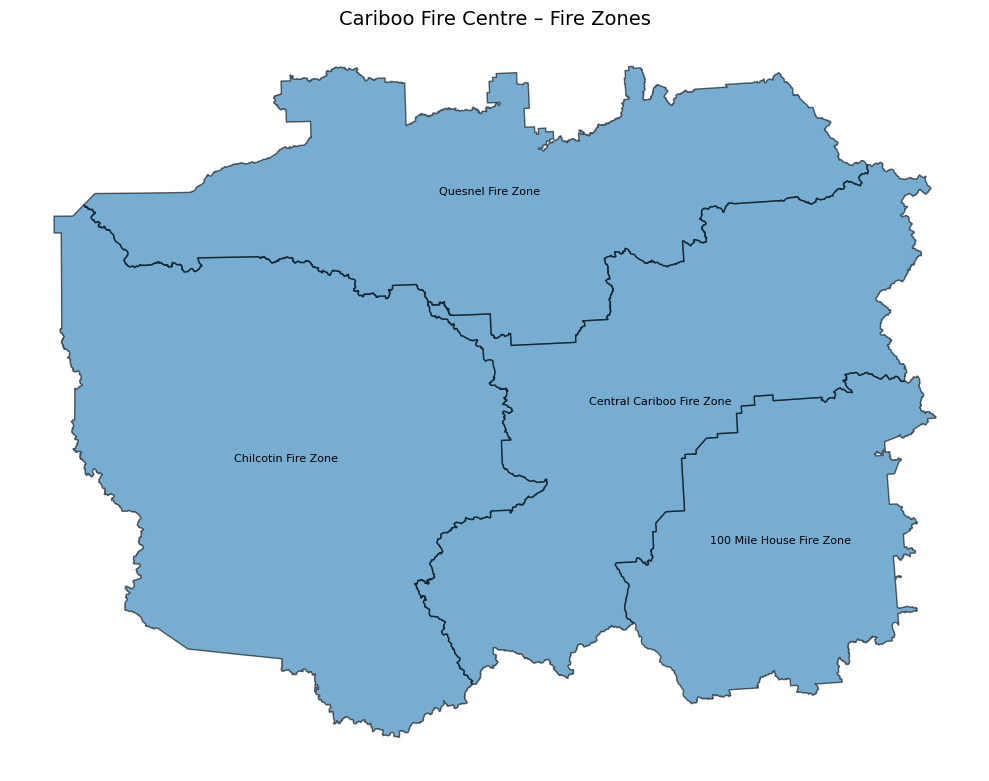

In [5]:
gdf = gdf.to_crs(epsg=3005)
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1,
    alpha=0.6
)

# Label fire zones
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["MOF_FIRE_ZONE_NAME"],
        fontsize=8,
        ha="center"
    )

ax.set_title("Cariboo Fire Centre – Fire Zones", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [6]:
#next is the weather data extraction bounding box region that are going to be used fpr fetching the weather data through different APIs

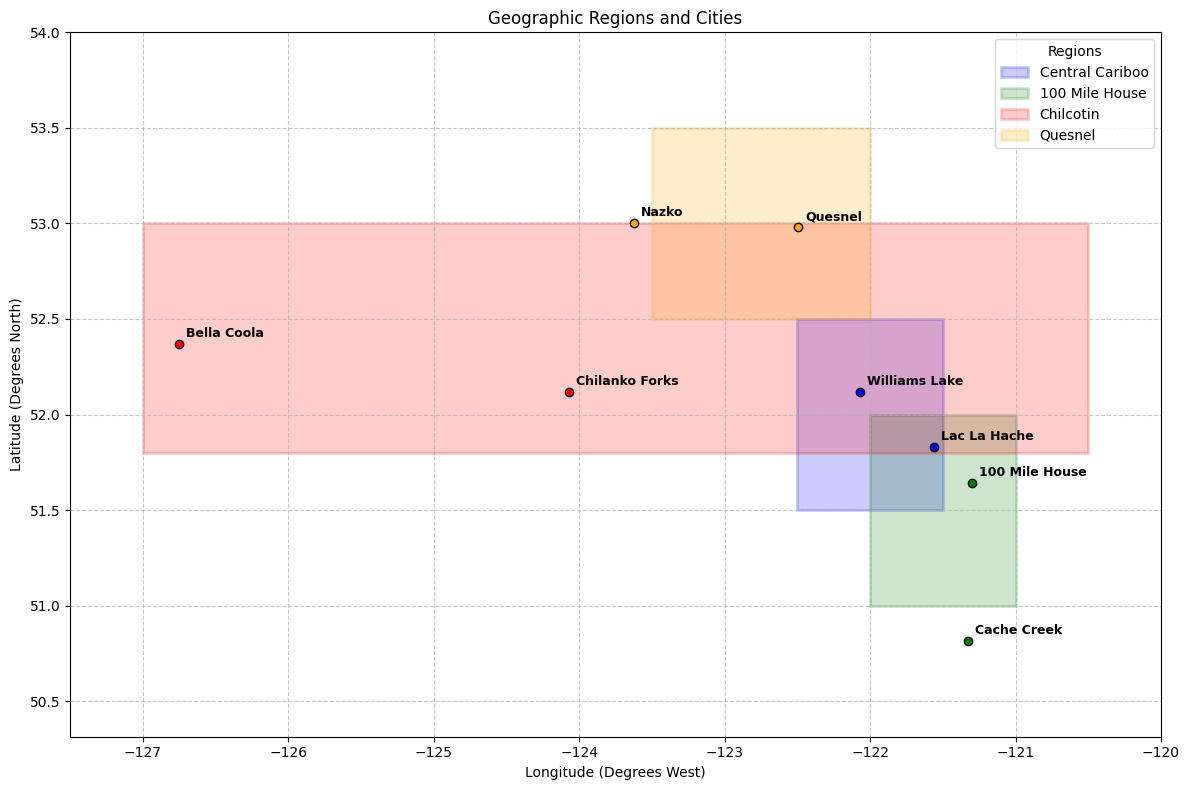

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define the regions, their boundaries, and associated cities with coordinates
regions = {
    "Central Cariboo": {
        "N": 52.5, "S": 51.5, "E": -121.5, "W": -122.5,
        "cities": {
            "Williams Lake": (52.117, -122.072),
            "Lac La Hache": (51.830, -121.560)
        },
        "color": "blue"
    },
    "100 Mile House": {
        "N": 52.0, "S": 51.0, "E": -121.0, "W": -122.0,
        "cities": {
            "100 Mile House": (51.643, -121.296),
            "Cache Creek": (50.814, -121.327)
        },
        "color": "green"
    },
    "Chilcotin": {
        "N": 53.0, "S": 51.8, "E": -120.5, "W": -127.0,
        "cities": {
            "Bella Coola": (52.370, -126.750),
            "Chilanko Forks": (52.117, -124.067)
        },
        "color": "red"
    },
    "Quesnel": {
        "N": 53.5, "S": 52.5, "E": -122.0, "W": -123.5,
        "cities": {
            "Quesnel": (52.980, -122.494),
            "Nazko": (53.000, -123.620)
        },
        "color": "orange"
    }
}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Iterate through regions to plot rectangles and cities
for name, data in regions.items():
    # Calculate width and height for the rectangle
    width = data["E"] - data["W"]
    height = data["N"] - data["S"]
    
    # Create a rectangle patch (Anchor point is West, South)
    rect = patches.Rectangle(
        (data["W"], data["S"]), width, height,
        linewidth=2, edgecolor=data["color"], facecolor=data["color"], 
        alpha=0.2, label=name
    )
    ax.add_patch(rect)
    
    # Plot cities
    for city_name, coords in data["cities"].items():
        lat, lon = coords
        # Plot point
        ax.scatter(lon, lat, color=data["color"], zorder=5, edgecolor='black')
        # Add label
        ax.annotate(city_name, (lon, lat), 
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, weight='bold')

# Formatting the plot
ax.set_xlabel("Longitude (Degrees West)")
ax.set_ylabel("Latitude (Degrees North)")
ax.set_title("Geographic Regions and Cities")
ax.legend(loc='upper right', title="Regions")
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust axis limits to fit all elements plus a margin
all_lons = [c[1] for r in regions.values() for c in r["cities"].values()] + \
           [r["E"] for r in regions.values()] + [r["W"] for r in regions.values()]
all_lats = [c[0] for r in regions.values() for c in r["cities"].values()] + \
           [r["N"] for r in regions.values()] + [r["S"] for r in regions.values()]

ax.set_xlim(min(all_lons) - 0.5, max(all_lons) + 0.5)
ax.set_ylim(min(all_lats) - 0.5, max(all_lats) + 0.5)

# Save or show the plot
plt.tight_layout()
plt.show()

In [8]:
#now we will overlay the bounding box on the official cariboo boundary to seee how well they align

Fetching official fire zones...


C:\Users\rajpu\AppData\Local\Temp\ipykernel_19224\1293487550.py:100: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  current_handles, current_labels = ax.get_legend_handles_labels()


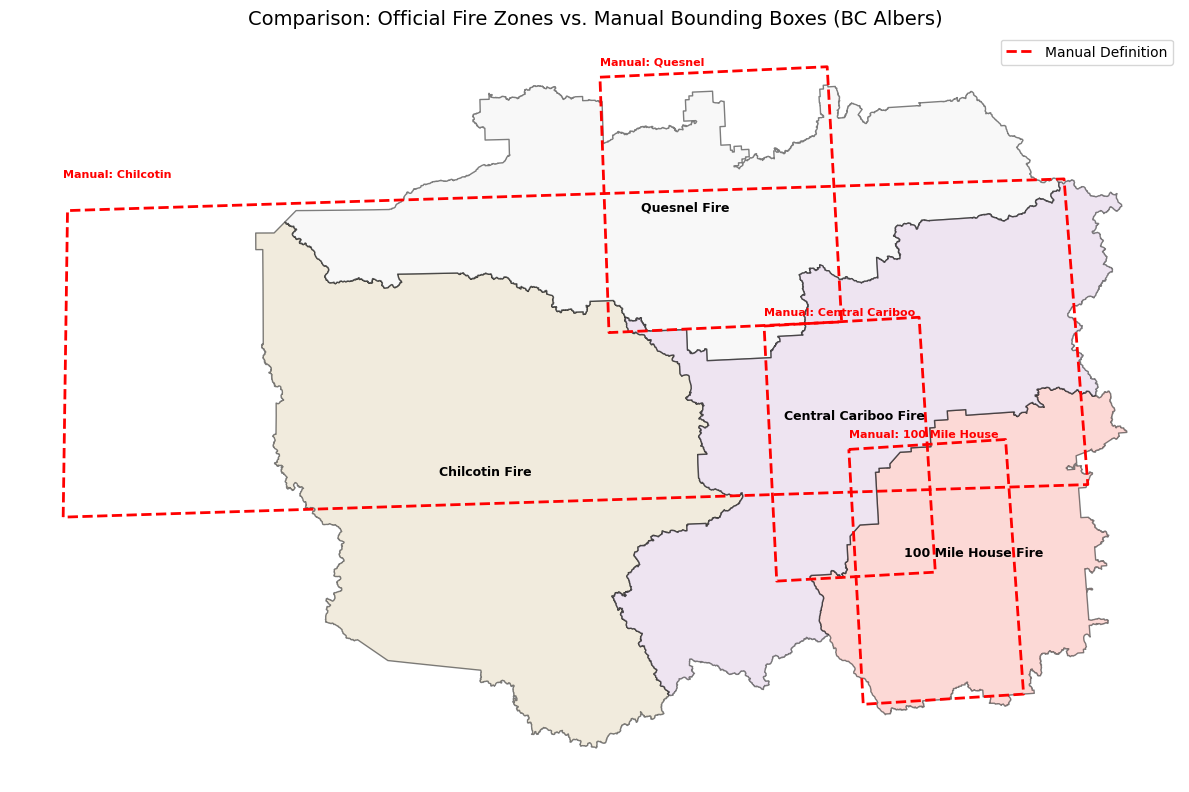

In [9]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO
from shapely.geometry import box, Point
import pandas as pd

# ---------------------------------------------------------
# 1. Fetch Official Data (WFS)
# ---------------------------------------------------------
WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"
}

print("Fetching official fire zones...")
response = requests.get(WFS_URL, params=params)
response.raise_for_status()

# Load into GeoDataFrame and reproject to BC Albers (EPSG:3005)
official_gdf = gpd.read_file(BytesIO(response.content))
official_gdf = official_gdf.to_crs(epsg=3005)

# ---------------------------------------------------------
# 2. Define Manual Regions (Lat/Lon)
# ---------------------------------------------------------
manual_data = {
    "Region": ["Central Cariboo", "100 Mile House", "Chilcotin", "Quesnel"],
    "N": [52.5, 52.0, 53.0, 53.5],
    "S": [51.5, 51.0, 51.8, 52.5],
    "E": [-121.5, -121.0, -120.5, -122.0],
    "W": [-122.5, -122.0, -127.0, -123.5]
}

# Create geometry boxes (West, South, East, North)
geometries = [box(w, s, e, n) for w, s, e, n in zip(manual_data["W"], manual_data["S"], manual_data["E"], manual_data["N"])]

# Create GeoDataFrame in WGS84 (EPSG:4326)
manual_gdf = gpd.GeoDataFrame(manual_data, geometry=geometries, crs="EPSG:4326")

# Reproject manual regions to match the official data (EPSG:3005)
manual_gdf = manual_gdf.to_crs(official_gdf.crs)

# ---------------------------------------------------------
# 3. Plot Comparison
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

# Plot A: Official Zones (Filled Polygons)
official_gdf.plot(
    ax=ax,
    column="MOF_FIRE_ZONE_NAME",
    cmap="Pastel1",
    edgecolor="black",
    linewidth=1,
    alpha=0.5,
    legend=True,
    legend_kwds={'loc': 'lower left', 'title': 'Official Zones'}
)

# Plot B: Manual Regions (Dashed Outlines)
manual_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    linestyle="--",
    label="Manual Bounding Box"
)

# ---------------------------------------------------------
# 4. Annotation
# ---------------------------------------------------------

# Label Official Zones
for idx, row in official_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["MOF_FIRE_ZONE_NAME"].replace(" Zone", ""), 
            fontsize=9, ha="center", weight="bold", color="black")

# Label Manual Boxes (offset slightly to avoid overlap)
for idx, row in manual_gdf.iterrows():
    # Get the top-left corner of the projected box for labeling
    bounds = row.geometry.bounds # (minx, miny, maxx, maxy)
    ax.text(bounds[0], bounds[3], f"Manual: {row['Region']}", 
            fontsize=8, color="red", weight="bold", ha="left", va="bottom")

# Formatting
ax.set_title("Comparison: Official Fire Zones vs. Manual Bounding Boxes (BC Albers)", fontsize=14)
ax.set_axis_off()

# Create a custom legend handle for the red dashed line
import matplotlib.lines as mlines
red_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='Manual Definition')
current_handles, current_labels = ax.get_legend_handles_labels()
# Add the red line to the existing legend logic isn't straightforward with geopandas plot, 
# so we add a secondary legend or just rely on the on-map red labels.
# Simple text annotation for legend:
ax.legend(handles=[red_line], loc='upper right')

plt.tight_layout()
plt.show()

The concept you are describing—where a mismatch between the spatial units of your target variable (official polygons) and your input features (weather bounding boxes) degrades model performance—is formally known in geospatial science as the Modifiable Areal Unit Problem (MAUP) and in machine learning as Spatial Label Noise.

The most direct and modern reference for this specific problem (spatial mismatch causing label noise in ML) is Hell & Brandmeier (2024).

This paper explicitly states that "spatial mismatch of the label and input data" introduces label noise that significantly decreases classification performance, which directly validates your "cookie cutter" solution.
Primary Reference Paper
Citation: Hell, M., & Brandmeier, M. (2024). Identifying plausible labels from noisy training data for a land use and land cover classification application in Amazônia Legal. Remote Sensing, 16(12), 2080. https://doi.org/10.3390/rs16122080

In [10]:
# code to look how much mismatch is there between the two boundary definitions

In [11]:
import geopandas as gpd



# 1. Calculate the intersection (where they agree)
intersection = gpd.overlay(manual_gdf, official_gdf, how='intersection')

# 2. Calculate areas
manual_area = manual_gdf.area.sum()
official_area = official_gdf.area.sum()
intersection_area = intersection.area.sum()

# 3. Calculate Mismatch
# How much of the Official Zone did we miss? (False Negatives)
missed_area_pct = (official_area - intersection_area) / official_area * 100

# How much extra land did we include? (Noise/False Positives)
extra_area_pct = (manual_area - intersection_area) / manual_area * 100

print(f"Missed {missed_area_pct:.2f}% of the real fire zones.")
print(f"Included {extra_area_pct:.2f}% of irrelevant land.")

Missed 14.51% of the real fire zones.
Included 17.59% of irrelevant land.


In [16]:

class CaribooBoundaryProcessor:
    def __init__(self, official_zones_gdf=None):
        self.zones_gdf = official_zones_gdf


    def _generate_valid_grid_points(self, polygon, resolution=0.1):
        """
        Generates a grid of lat/lon points and keeps only those INSIDE the polygon.
        resolution: Step size in degrees (0.1 deg ~= 11km)
        """
        # ---------------------------------------------------------
        # CRITICAL FIX: Unit Alignment
        # 1. Convert the single polygon to WGS84 (Lat/Lon) to get bounds in Degrees
        # ---------------------------------------------------------
        poly_geo = gpd.GeoSeries([polygon], crs=self.zones_gdf.crs)
        poly_wgs84 = poly_geo.to_crs("EPSG:4326").iloc[0]
        
        minx, miny, maxx, maxy = poly_wgs84.bounds
        
        # 2. Generate Grid (Now using correct Degree units)
        lats = np.arange(miny, maxy, resolution)
        lons = np.arange(minx, maxx, resolution)
        grid_points = []
        
        for lat in lats:
            for lon in lons:
                grid_points.append(Point(lon, lat))
        
        if not grid_points:
            print("   ! Warning: Grid generation produced 0 points. Check resolution.")
            return []

        # 3. Filter Points (The Cookie Cutter)
        # We create the grid in WGS84...
        grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs="EPSG:4326")
        
        # ...but we project it to BC Albers (Meters) to match the official polygon 
        # for the most accurate inclusion test (Spatial Join)
        grid_gdf_proj = grid_gdf.to_crs(self.zones_gdf.crs)
        poly_gdf_proj = gpd.GeoDataFrame(geometry=[polygon], crs=self.zones_gdf.crs)
        
        valid_points_gdf = gpd.sjoin(grid_gdf_proj, poly_gdf_proj, how="inner", predicate="within")
        
        # 4. Convert valid points back to Lat/Lon for the API
        valid_points_gdf = valid_points_gdf.to_crs("EPSG:4326")
        
        print(f"   > Grid Generation: Created {len(grid_points)} candidates -> Kept {len(valid_points_gdf)} valid points inside zone.")
        return list(zip(valid_points_gdf.geometry.y, valid_points_gdf.geometry.x))
    


In [ ]:
# 1. Load the Official Shapefile first
import geopandas as gpd
from io import BytesIO
import requests

WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"
params = {"service": "WFS", "version": "2.0.0", "request": "GetFeature", 
          "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
          "outputFormat": "application/json", "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"}

official_gdf = gpd.read_file(BytesIO(requests.get(WFS_URL, params=params).content))
official_gdf = official_gdf.to_crs(epsg=3005) 

fetcher = CaribooBoundaryProcessor(official_gdf)


In [22]:
official_gdf.head()

,id,MOF_FIRE_ZONE_ID,MOF_FIRE_CENTRE_NAME,MOF_FIRE_ZONE_NAME,HEADQUARTERS_CITY_NAME,OBJECTID,SE_ANNO_CAD_DATA,FEATURE_AREA_SQM,FEATURE_LENGTH_M,geometry
0,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,493,Cariboo Fire Centre,100 Mile House Fire Zone,100 Mile House,1104,None,1.236059e+10,7.452190e+05,"POLYGON ((1365595.79 811388.999, 1365587.148 8..."
1,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,496,Cariboo Fire Centre,Chilcotin Fire Zone,Williams Lake,1107,None,2.871304e+10,1.146598e+06,"POLYGON ((1176324.025 842019.703, 1176323.53 8..."
2,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,498,Cariboo Fire Centre,Quesnel Fire Zone,Quesnel,1109,None,2.077233e+10,1.337766e+06,"POLYGON ((1264933.277 942501.98, 1264888.802 9..."
3,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,510,Cariboo Fire Centre,Central Cariboo Fire Zone,Williams Lake,1121,None,2.063411e+10,1.316524e+06,"POLYGON ((1393202.155 890463.295, 1393201.79 8..."


In [25]:
print("Official Fire Zones: with their ids and names")

for idx, row in official_gdf.iterrows():
    print(f"ID: {idx}, Name: {row['MOF_FIRE_ZONE_NAME']}")

Official Fire Zones: with their ids and names
ID: 0, Name: 100 Mile House Fire Zone
ID: 1, Name: Chilcotin Fire Zone
ID: 2, Name: Quesnel Fire Zone
ID: 3, Name: Central Cariboo Fire Zone


Found 4 zones to visualize.

Visualizing: 100 Mile House Fire Zone...
   > Grid Generation: Created 273 candidates -> Kept 161 valid points inside zone.


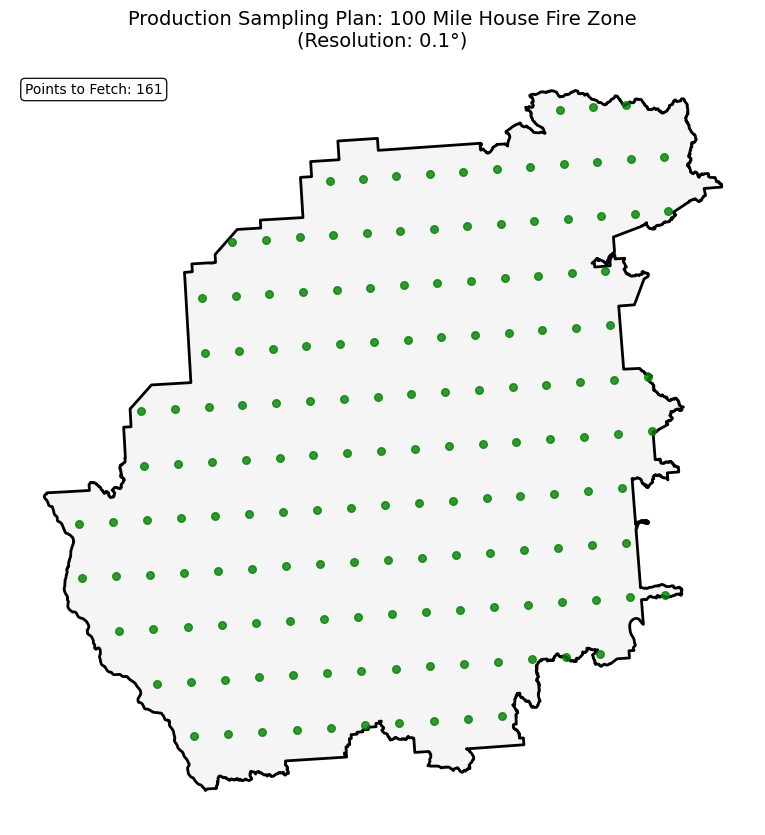

Visualizing: Chilcotin Fire Zone...
   > Grid Generation: Created 651 candidates -> Kept 375 valid points inside zone.


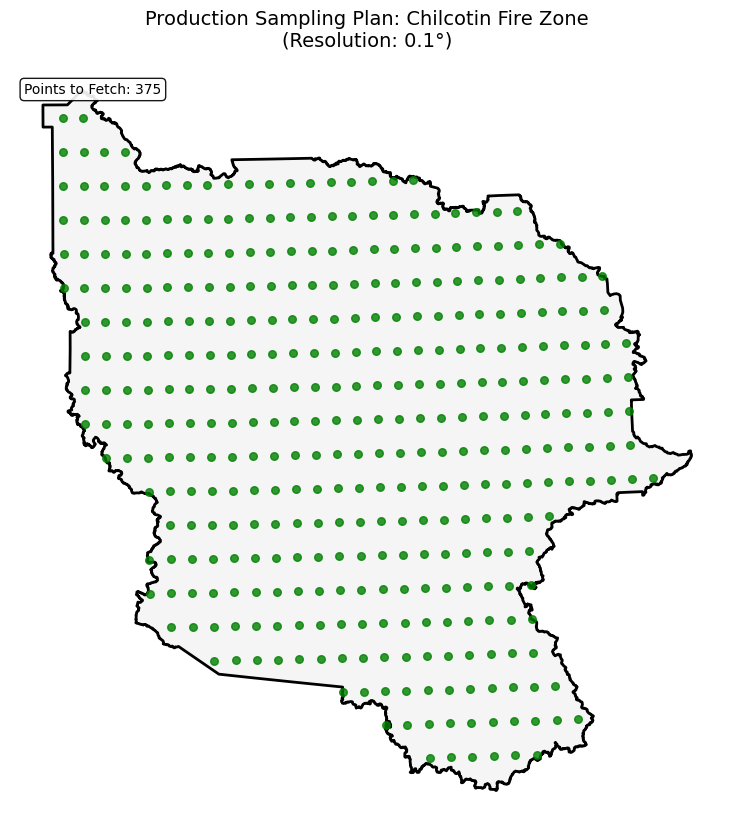

Visualizing: Quesnel Fire Zone...
   > Grid Generation: Created 612 candidates -> Kept 280 valid points inside zone.


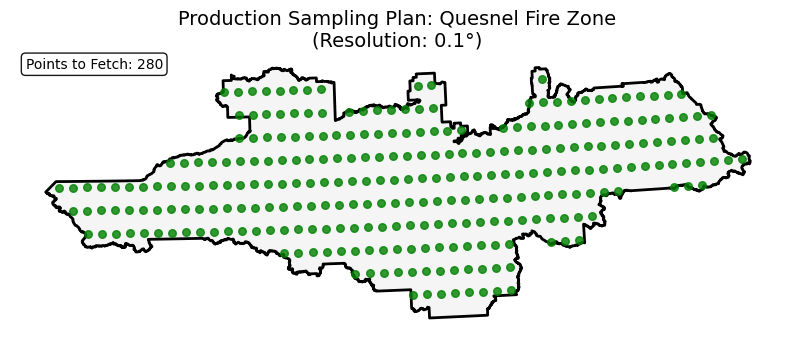

Visualizing: Central Cariboo Fire Zone...
   > Grid Generation: Created 700 candidates -> Kept 273 valid points inside zone.


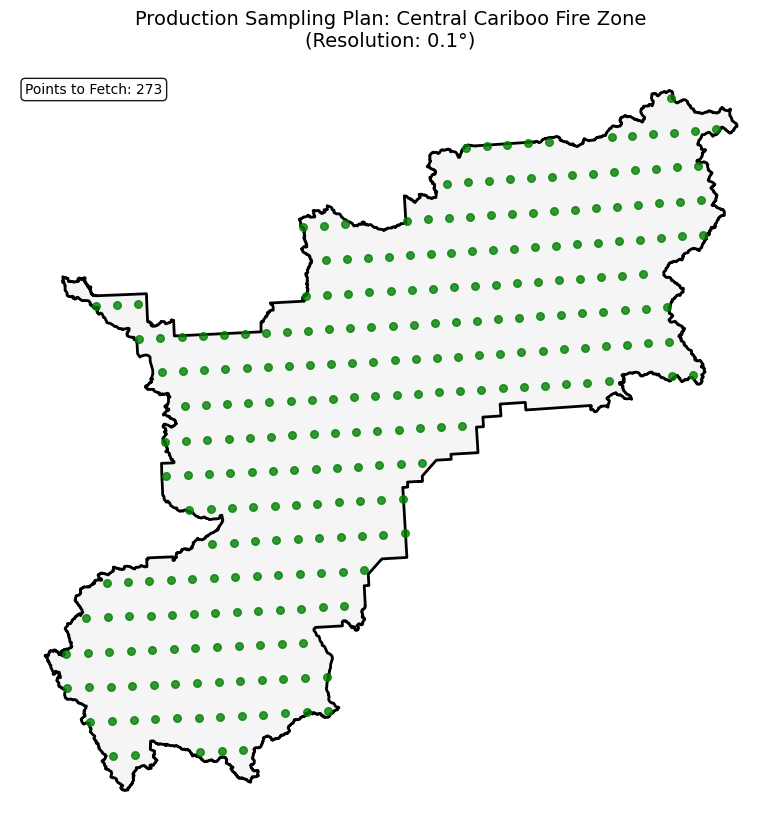

In [18]:

unique_zones = official_gdf['MOF_FIRE_ZONE_NAME'].unique()
print(f"Found {len(unique_zones)} zones to visualize.\n")

for zone_name in unique_zones:
    print(f"Visualizing: {zone_name}...")
  
    target_row = official_gdf[official_gdf['MOF_FIRE_ZONE_NAME'] == zone_name]
    polygon = target_row.geometry.iloc[0]
    
   
    valid_coords = fetcher._generate_valid_grid_points(polygon, resolution=0.1)
    
    if not valid_coords:
        print(f"   ! WARNING: No points generated for {zone_name}")
        continue

   
    points_geom = [Point(lon, lat) for lat, lon in valid_coords]
    points_gdf = gpd.GeoDataFrame(geometry=points_geom, crs="EPSG:4326")
    
    # Project points to match the map (BC Albers)
    points_gdf = points_gdf.to_crs(official_gdf.crs)
    target_poly_gdf = gpd.GeoDataFrame(geometry=[polygon], crs=official_gdf.crs)

    # D. PLOT
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 1. Draw the Zone Boundary
    target_poly_gdf.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=2, zorder=1)
    
    # 2. Draw the Valid Points (Output from Function)
    points_gdf.plot(ax=ax, color='green', marker='o', markersize=30, alpha=0.8, label='Valid Grid Points', zorder=2)
    
    # Formatting
    plt.title(f"Production Sampling Plan: {zone_name}\n(Resolution: 0.1°)", fontsize=14)
    plt.axis('off')
    
    # Stats Text
    plt.text(0.02, 0.95, f"Points to Fetch: {len(points_gdf)}", transform=ax.transAxes,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    # Save
    plt.show()
    safe_name = zone_name.replace(" ", "_").lower()
    plt.close() # Close memory to prevent crash
    
   

